# **Project Overview**
# **Healthcare Analytics for Doctor Visits**
# **TIRTC** **Project**

# **1**. **Import** **Libraries**

In [628]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

# **2**. **Load** **the** **Uploaded** **Dataset**

In [629]:
# Update this path if running outside Google Colab
file_path = "/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv"

df = pd.read_csv(file_path)
print(f"Dataset loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 5,190 rows and 13 columns


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


# **Data** **Inspection** **and** **Cleaning**

## **3**. **Initial** **Dataset** **Inspection**

In [630]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (5190, 13)

Column names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

Data types:


,dtype
Unnamed: 0,int64
visits,int64
gender,object
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,object
freepoor,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [631]:
# First and last observations
display(df.head())
display(df.tail())

# Statistical summary
display(df.describe(include="all").T)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,"5,190.00",NaN,NaN,NaN,"2,595.50","1,498.37",1.00,"1,298.25","2,595.50","3,892.75","5,190.00"
visits,"5,190.00",NaN,NaN,NaN,0.30,0.80,0.00,0.00,0.00,0.00,9.00
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"5,190.00",NaN,NaN,NaN,0.41,0.20,0.19,0.22,0.32,0.62,0.72
income,"5,190.00",NaN,NaN,NaN,0.58,0.37,0.00,0.25,0.55,0.90,1.50
illness,"5,190.00",NaN,NaN,NaN,1.43,1.38,0.00,0.00,1.00,2.00,5.00
reduced,"5,190.00",NaN,NaN,NaN,0.86,2.89,0.00,0.00,0.00,0.00,14.00
health,"5,190.00",NaN,NaN,NaN,1.22,2.12,0.00,0.00,0.00,2.00,12.00
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4**. **Data** **Quality** **Check** **and** **Cleaning**

# The uploaded data contains an Unnamed: 0 column that functions as an index/record identifier rather than an analytical feature. It is removed from the analysis. Missing values, duplicate records, and categorical levels are also checked before analysis.   

In [632]:
# Work on a copy
data = df.copy()

# Remove CSV index-like column if present
index_like_cols = [c for c in data.columns if c.lower().startswith("unnamed")]
data = data.drop(columns=index_like_cols, errors="ignore")

# Missing values
missing = data.isnull().sum().sort_values(ascending=False)
missing_pct = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_report = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
display(missing_report)

# Duplicate rows
print("Duplicate rows:", data.duplicated().sum())

# Remove exact duplicates
data = data.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", data.shape)

,missing_count,missing_percent
visits,0,0.00
gender,0,0.00
age,0,0.00
income,0,0.00
illness,0,0.00
reduced,0,0.00
health,0,0.00
private,0,0.00
freepoor,0,0.00
freerepat,0,0.00


Duplicate rows: 1320
Shape after cleaning: (3870, 12)


In [633]:
# Inspect categorical variables
categorical_cols = data.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts(dropna=False))

# Numeric columns
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
print("\nNumeric columns:", numeric_cols)


gender:
gender
female    2068
male      1802
Name: count, dtype: int64

private:
private
no     2088
yes    1782
Name: count, dtype: int64

freepoor:
freepoor
no     3676
yes     194
Name: count, dtype: int64

freerepat:
freerepat
no     3102
yes     768
Name: count, dtype: int64

nchronic:
nchronic
no     2192
yes    1678
Name: count, dtype: int64

lchronic:
lchronic
no     3294
yes     576
Name: count, dtype: int64

Numeric columns: ['visits', 'age', 'income', 'illness', 'reduced', 'health']


# **5**. **Project** **Problem** **Statement**

# Healthcare providers and planners need to understand patterns in doctor visits across demographic, socioeconomic, health-status, and healthcare-access variables. This project uses historical visit records to identify descriptive patterns in utilization and highlight factors that may warrant further investigation.

# **6 . **Key** **Dataset** Variables**
*   `visits` – recorded number of doctor visits; primary outcome for this analysis.
*   `gender` – patient gender category.
*   `age` – age value recorded in the dataset.
*   `income` – income-related numeric measure.
*   `illness` – illness count/score recorded for the patient.
*   `reduced` – reduced-activity measure.
*   `health` – health-status measure.
*   `private` – private insurance indicator.
*   `freepoor` – free-care indicator associated with poverty eligibility.
*   `freerepat` – free/repatriation-care indicator.
*   `nchronic` – indicator for chronic condition category.
*   `lchronic` – indicator for another chronic-condition category.

# **Exploratory** **Data** **Analysis**

# **7**. **Univariate** **Analysis** **–** **Gender** **Distribution**

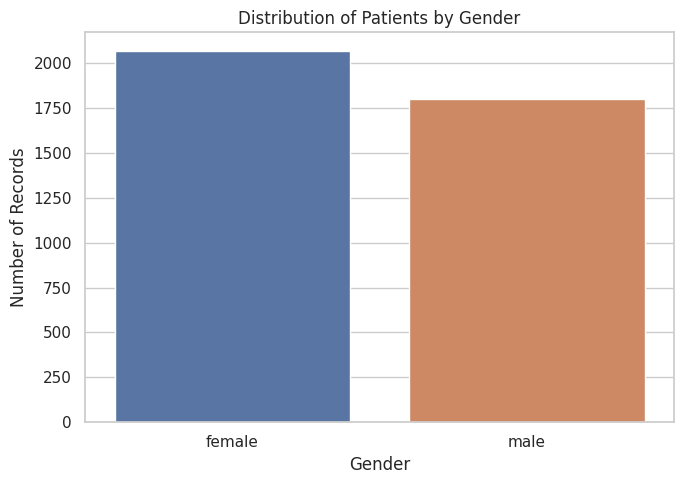

,gender,count
0,female,2068
1,male,1802


In [634]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="gender", hue="gender", legend=False)
plt.title("Distribution of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(data["gender"].value_counts().rename_axis("gender").reset_index(name="count"))

# **8**. **Univariate** **Analysis** **–** **Age** **Distribution**

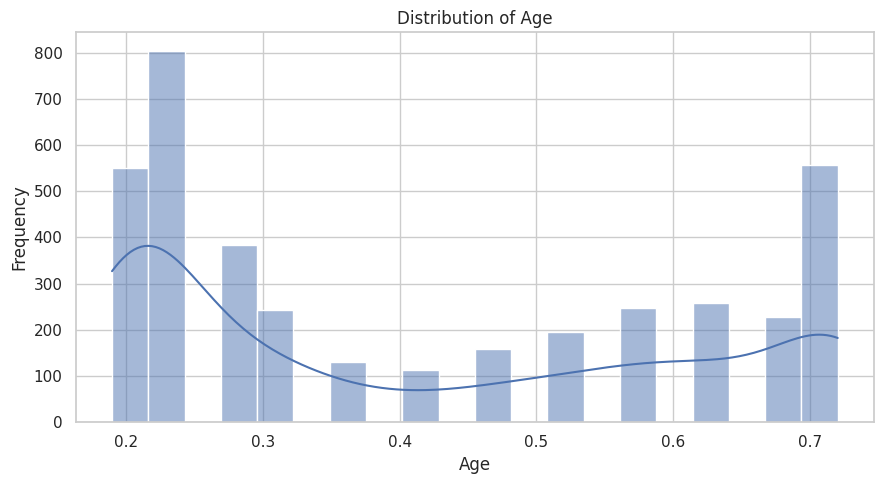

,age_summary
count,"3,870.00"
mean,0.41
std,0.20
min,0.19
25%,0.22
50%,0.32
75%,0.62
max,0.72


In [635]:
plt.figure(figsize=(9, 5))
sns.histplot(data["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(data["age"].describe().to_frame("age_summary"))

# **9**. **Univariate** **Analysis** **–** **Doctor** **Visits**

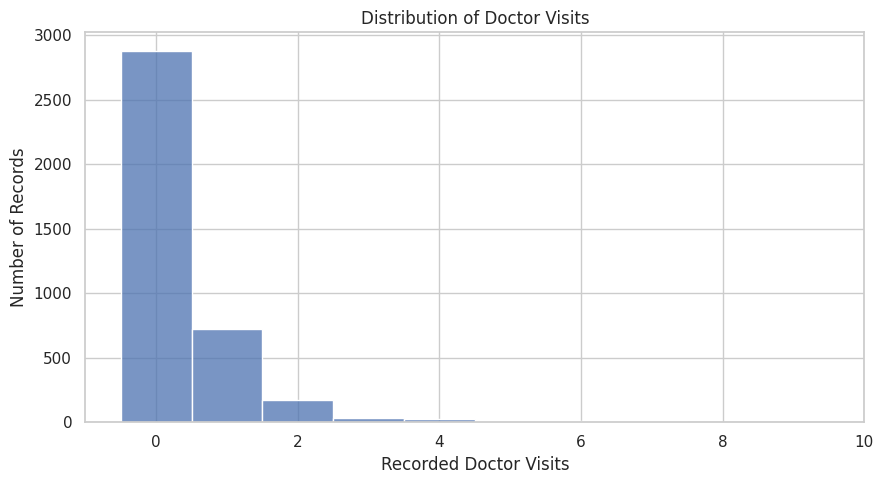

,visits_summary
count,"3,870.00"
mean,0.39
std,0.90
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,9.00


In [636]:
plt.figure(figsize=(9, 5))
bins = np.arange(data["visits"].min(), data["visits"].max() + 2) - 0.5
sns.histplot(data["visits"], bins=bins, discrete=True)
plt.title("Distribution of Doctor Visits")
plt.xlabel("Recorded Doctor Visits")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(data["visits"].describe().to_frame("visits_summary"))

# **10**. **Univariate** **Analysis** **–** **Income** **Distribution**

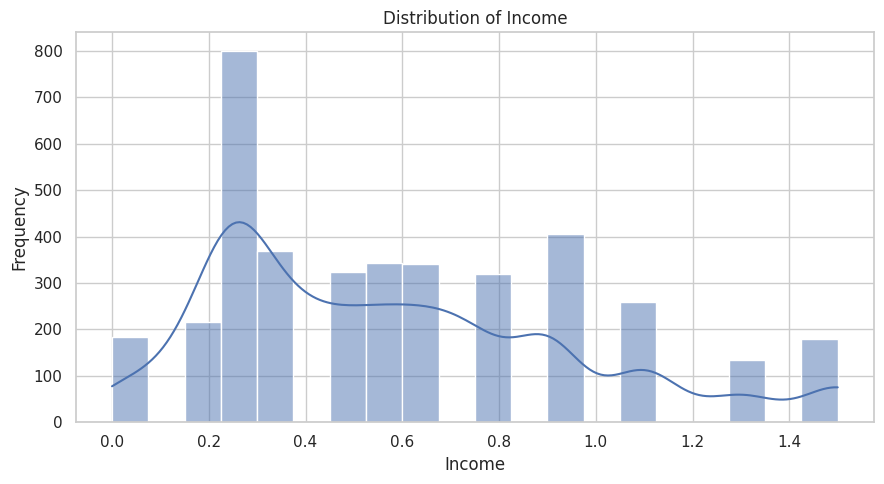

,income_summary
count,"3,870.00"
mean,0.58
std,0.38
min,0.00
25%,0.25
50%,0.55
75%,0.90
max,1.50


In [637]:
plt.figure(figsize=(9, 5))
sns.histplot(data["income"], bins=20, kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(data["income"].describe().to_frame("income_summary"))

# **11**. **Univariate** **Analysis** **–** **Illness** **Distribution**

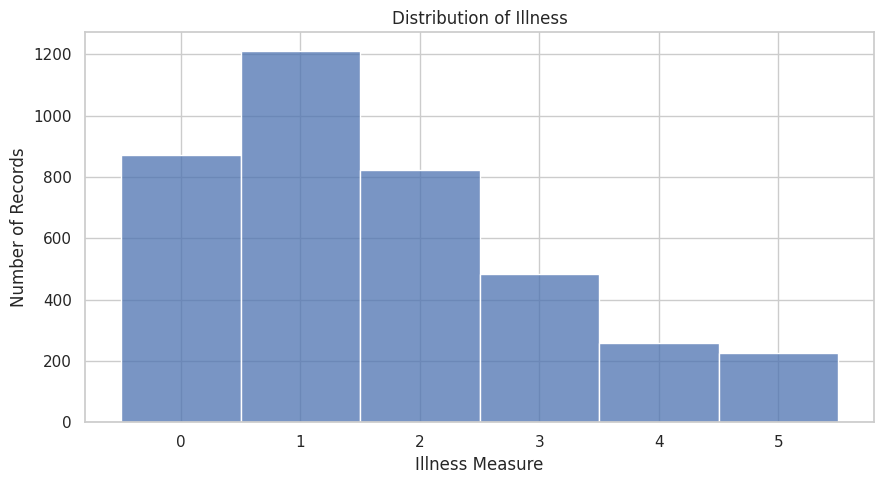

,illness_summary
count,"3,870.00"
mean,1.67
std,1.42
min,0.00
25%,1.00
50%,1.00
75%,2.75
max,5.00


In [638]:
plt.figure(figsize=(9, 5))
bins = np.arange(data["illness"].min(), data["illness"].max() + 2) - 0.5
sns.histplot(data["illness"], bins=bins, discrete=True)
plt.title("Distribution of Illness")
plt.xlabel("Illness Measure")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(data["illness"].describe().to_frame("illness_summary"))

# **12**. **Univariate** **Analysis** **–** **Reduced** **Activity** **Distribution**

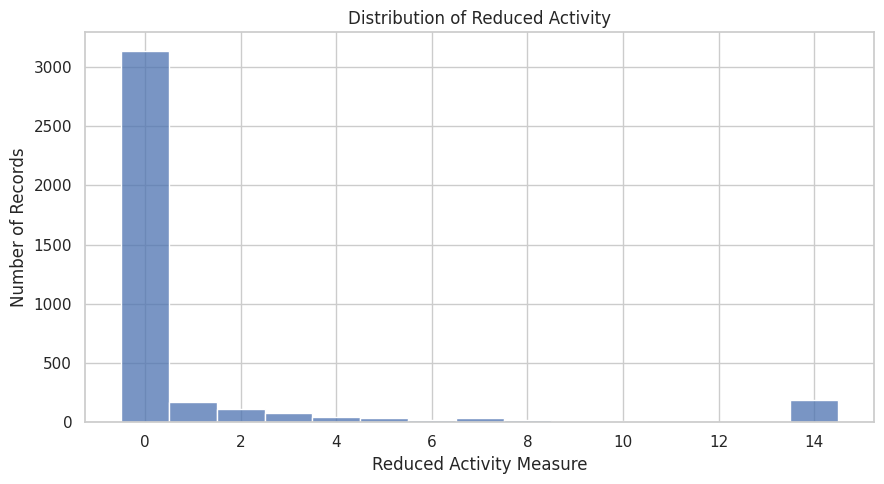

,reduced_summary
count,"3,870.00"
mean,1.15
std,3.29
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,14.00


In [639]:
plt.figure(figsize=(9, 5))
bins = np.arange(data["reduced"].min(), data["reduced"].max() + 2) - 0.5
sns.histplot(data["reduced"], bins=bins, discrete=True)
plt.title("Distribution of Reduced Activity")
plt.xlabel("Reduced Activity Measure")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(data["reduced"].describe().to_frame("reduced_summary"))

# **13**. **Univariate** **Analysis** **–** **Health** **Distribution**

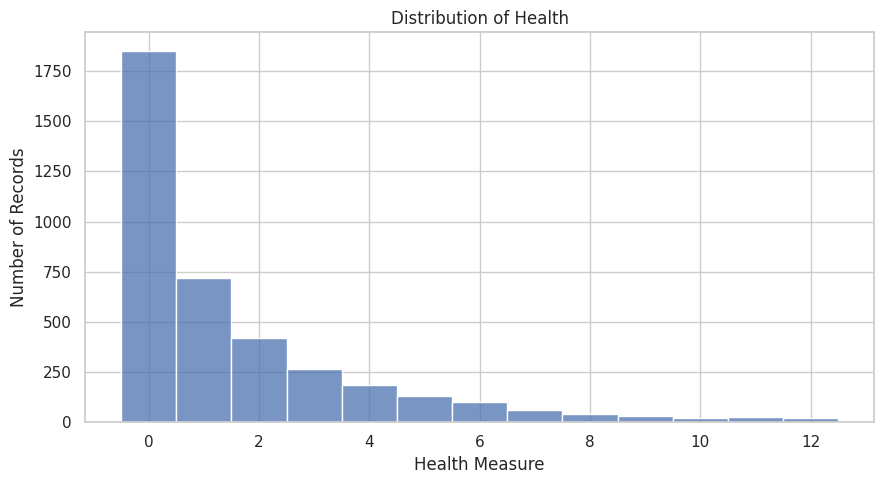

,health_summary
count,"3,870.00"
mean,1.58
std,2.33
min,0.00
25%,0.00
50%,1.00
75%,2.00
max,12.00


In [640]:
plt.figure(figsize=(9, 5))
bins = np.arange(data["health"].min(), data["health"].max() + 2) - 0.5
sns.histplot(data["health"], bins=bins, discrete=True)
plt.title("Distribution of Health")
plt.xlabel("Health Measure")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(data["health"].describe().to_frame("health_summary"))

## **14**. **Doctor** **Visits** **by** **Gender**

,gender,count,mean,median,std,min,max
0,female,2068,0.45,0.00,0.95,0,8
1,male,1802,0.32,0.00,0.83,0,9


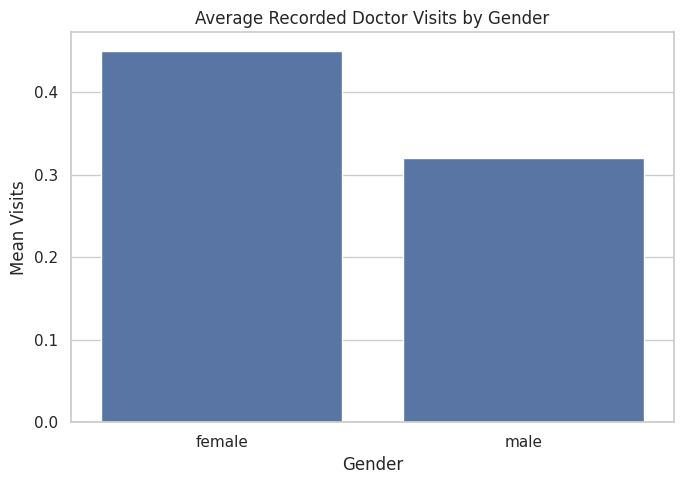

In [641]:
gender_analysis = (
    data.groupby("gender")["visits"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
display(gender_analysis)

plt.figure(figsize=(7, 5))
sns.barplot(data=gender_analysis, x="gender", y="mean")
plt.title("Average Recorded Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Visits")
plt.tight_layout()
plt.show()

# **15**. **Doctor** **Visits** **by** **Illness**

,illness,count,mean,median
0,0,870,0.13,0.00
1,1,1211,0.38,0.00
2,2,821,0.45,0.00
3,3,485,0.45,0.00
4,4,258,0.61,0.00
5,5,225,0.85,0.00


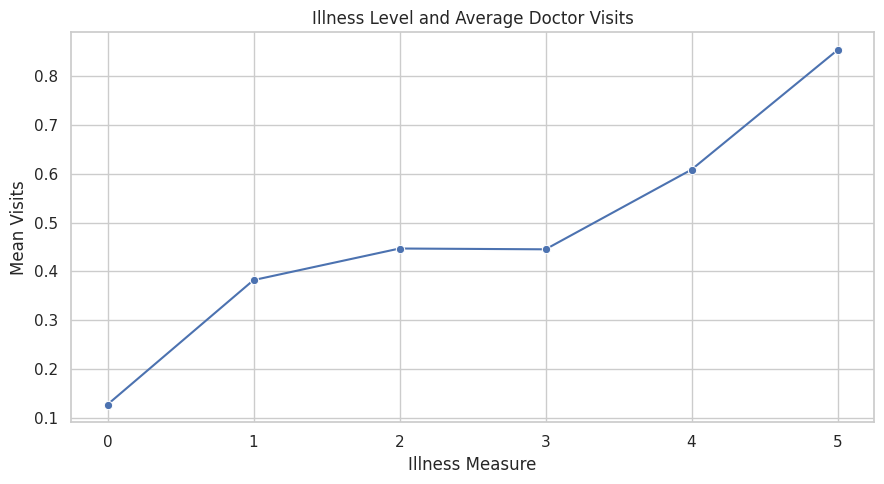

In [642]:
illness_analysis = (
    data.groupby("illness")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("illness")
)
display(illness_analysis)

plt.figure(figsize=(9, 5))
sns.lineplot(data=illness_analysis, x="illness", y="mean", marker="o")
plt.title("Illness Level and Average Doctor Visits")
plt.xlabel("Illness Measure")
plt.ylabel("Mean Visits")
plt.tight_layout()
plt.show()

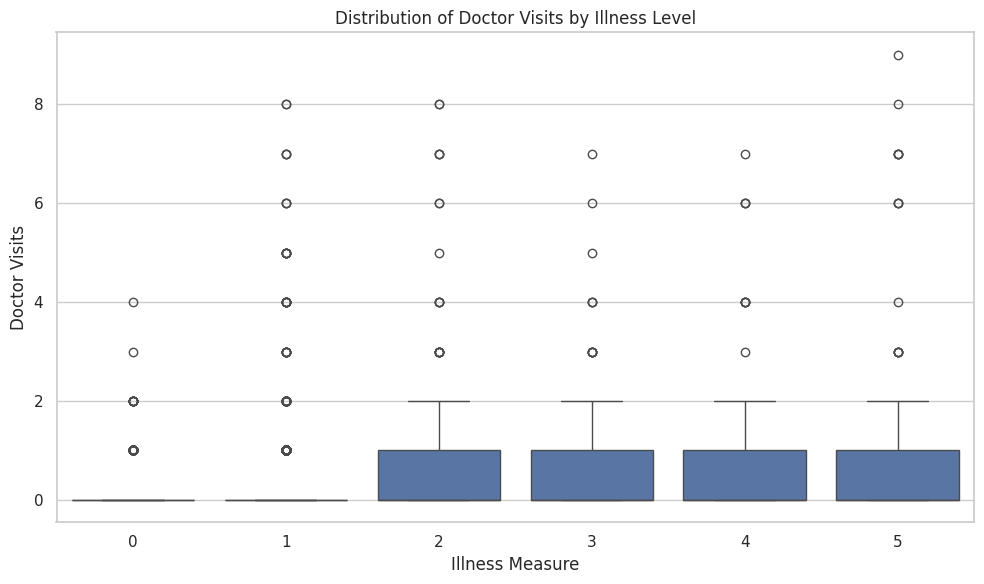

In [643]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="illness", y="visits")
plt.title("Distribution of Doctor Visits by Illness Level")
plt.xlabel("Illness Measure")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# **16**. **Doctor** **Visits** **by** **Health** **Status**

,health,count,mean,median
0,0,1851,0.30,0.00
1,1,719,0.37,0.00
2,2,419,0.40,0.00
3,3,264,0.42,0.00
4,4,185,0.54,0.00
5,5,132,0.53,0.00
6,6,102,0.64,0.00
7,7,61,0.92,0.00
8,8,41,0.49,0.00
9,9,32,0.66,0.00


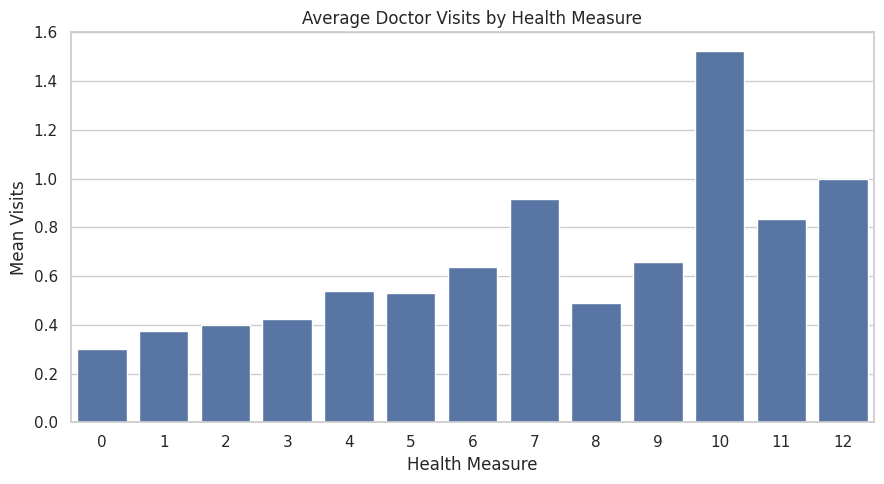

In [644]:
health_analysis = (
    data.groupby("health")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("health")
)
display(health_analysis)

plt.figure(figsize=(9, 5))
sns.barplot(data=health_analysis, x="health", y="mean")
plt.title("Average Doctor Visits by Health Measure")
plt.xlabel("Health Measure")
plt.ylabel("Mean Visits")
plt.tight_layout()
plt.show()

# **17**. **Age** **vs** **Doctor** **Visits**

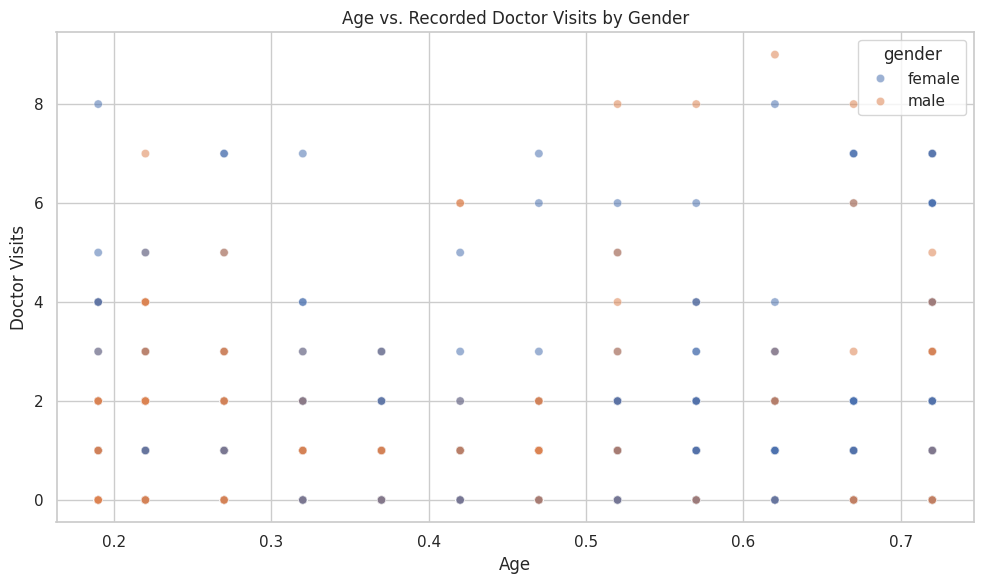

Pearson correlation between age and visits: 0.12383587027276968


In [645]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="age", y="visits", hue="gender", alpha=0.55)
plt.title("Age vs. Recorded Doctor Visits by Gender")
plt.xlabel("Age")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

print("Pearson correlation between age and visits:",
      data[["age", "visits"]].corr().loc["age", "visits"])

# **18**. **Distribution** **of** **Visits** **by** **Gender**

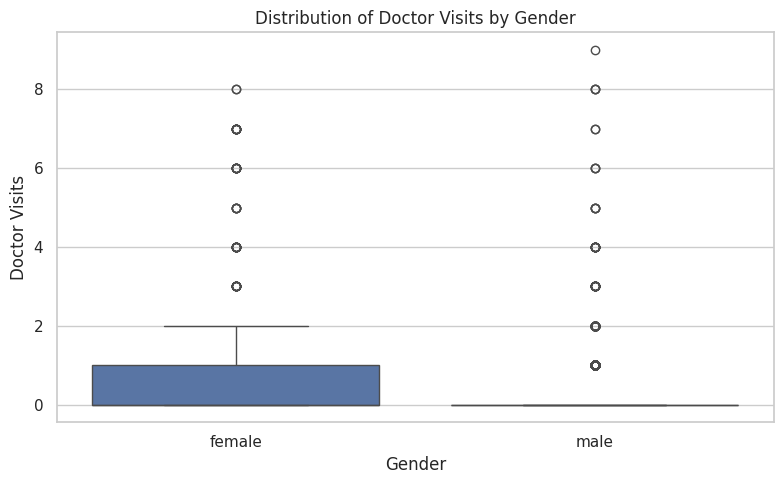

In [646]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="gender", y="visits", hue="gender", legend=False)
plt.title("Distribution of Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# **19**. **Healthcare** **Access** **/** **Coverage** **Variables**


## The following binary/categorical variables are examined descriptively against doctor visits: private, freepoor, freerepat, nchronic, and lchronic.   

In [647]:
access_cols = ["private", "freepoor", "freerepat", "nchronic", "lchronic"]

access_summary = []
for col in access_cols:
    tmp = data.groupby(col)["visits"].agg(["count", "mean", "median"]).reset_index()
    tmp.insert(0, "variable", col)
    tmp = tmp.rename(columns={col: "category"})
    access_summary.append(tmp)

access_summary = pd.concat(access_summary, ignore_index=True)
display(access_summary)

,variable,category,count,mean,median
0,private,no,2088,0.40,0.00
1,private,yes,1782,0.37,0.00
2,freepoor,no,3676,0.40,0.00
3,freepoor,yes,194,0.18,0.00
4,freerepat,no,3102,0.33,0.00
5,freerepat,yes,768,0.61,0.00
6,nchronic,no,2192,0.38,0.00
7,nchronic,yes,1678,0.41,0.00
8,lchronic,no,3294,0.35,0.00
9,lchronic,yes,576,0.63,0.00


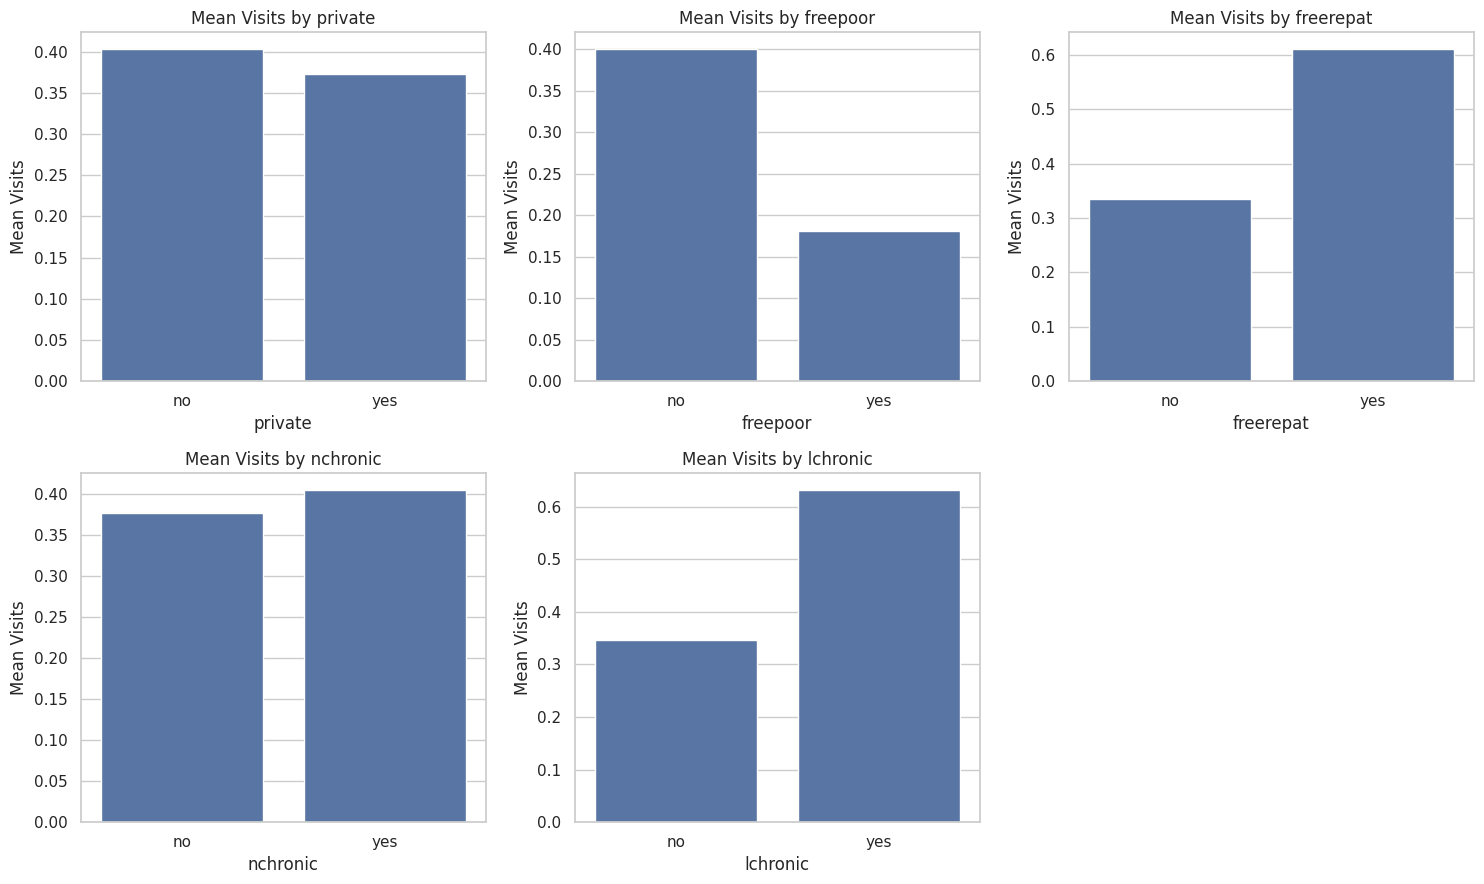

In [648]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, access_cols):
    summary = data.groupby(col)["visits"].mean().reset_index()
    sns.barplot(data=summary, x=col, y="visits", ax=ax)
    ax.set_title(f"Mean Visits by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Mean Visits")

# Hide unused subplot
for ax in axes[len(access_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## **20**. **Distribution** **of** **Doctor** **Visits** **by** **Private** **Insurance**

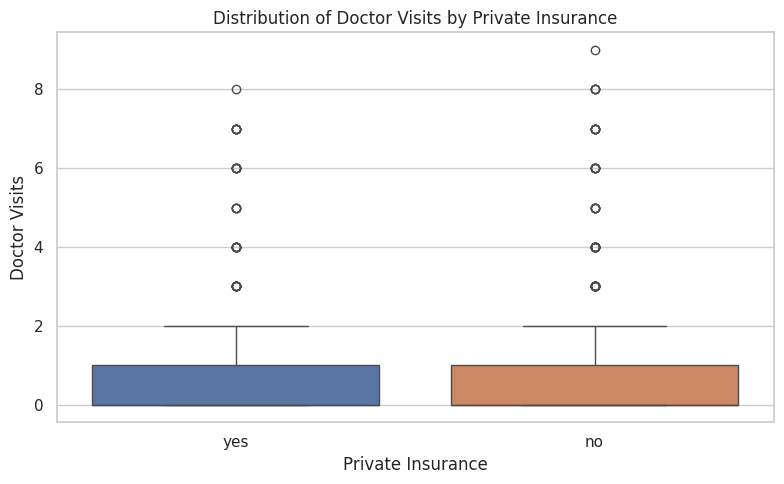

In [649]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="private", y="visits", hue="private", legend=False)
plt.title("Distribution of Doctor Visits by Private Insurance")
plt.xlabel("Private Insurance")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

## **21**. **Distribution** **of** **Doctor** **Visits** **by** **Free** **Poor** **Status**

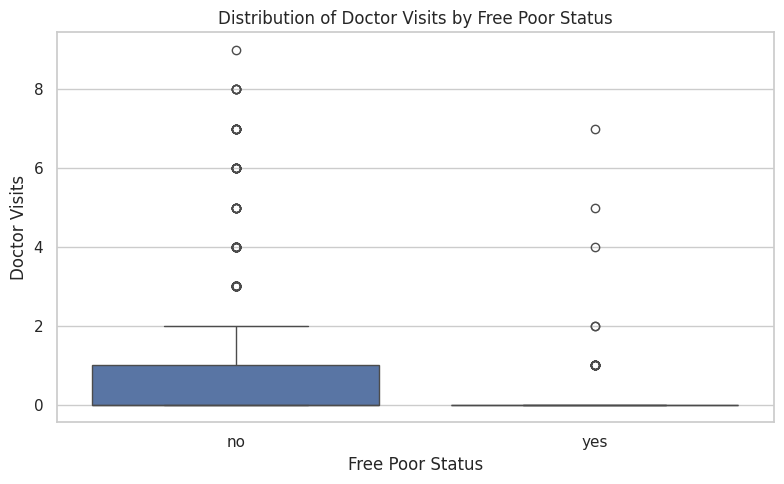

In [650]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="freepoor", y="visits", hue="freepoor", legend=False)
plt.title("Distribution of Doctor Visits by Free Poor Status")
plt.xlabel("Free Poor Status")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

## **22**. **Distribution** **of** **Doctor** **Visits** **by** **Free** **Repatriation** **Status**

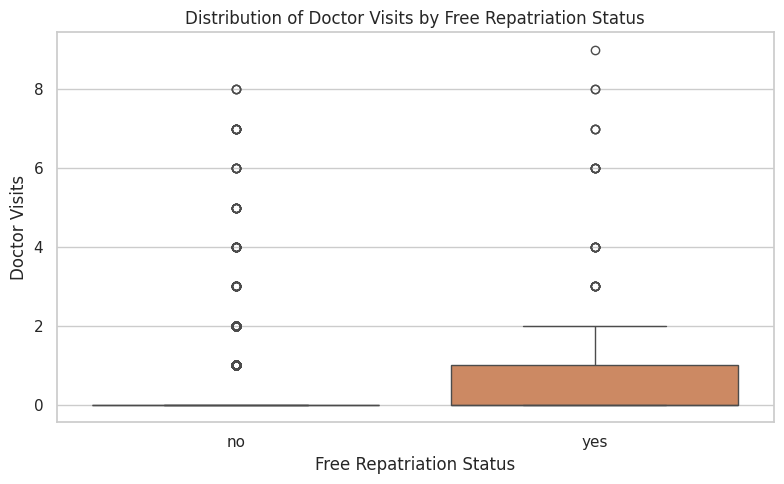

In [651]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="freerepat", y="visits", hue="freerepat", legend=False)
plt.title("Distribution of Doctor Visits by Free Repatriation Status")
plt.xlabel("Free Repatriation Status")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

## **23**. **Distribution** **of** **Doctor** **Visits** **by** **Chronic** **Condition** **(nchronic)**

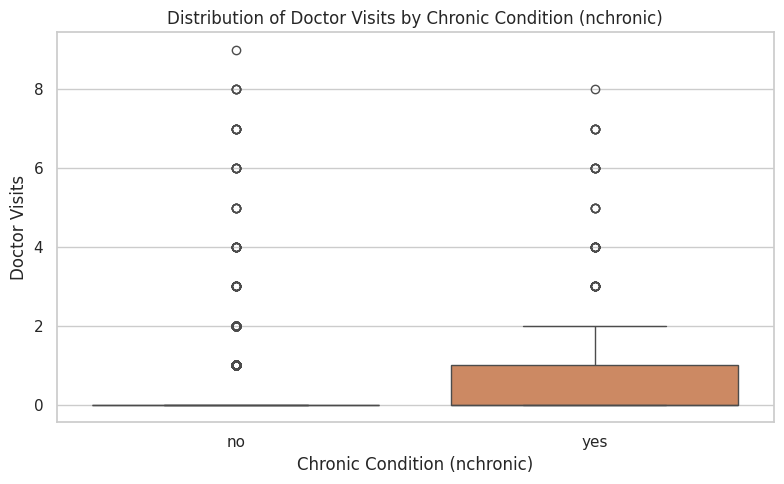

In [652]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="nchronic", y="visits", hue="nchronic", legend=False)
plt.title("Distribution of Doctor Visits by Chronic Condition (nchronic)")
plt.xlabel("Chronic Condition (nchronic)")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

## **24**. **Distribution** **of** **Doctor** **Visits** **by** **Chronic** **Condition** **(lchronic)**

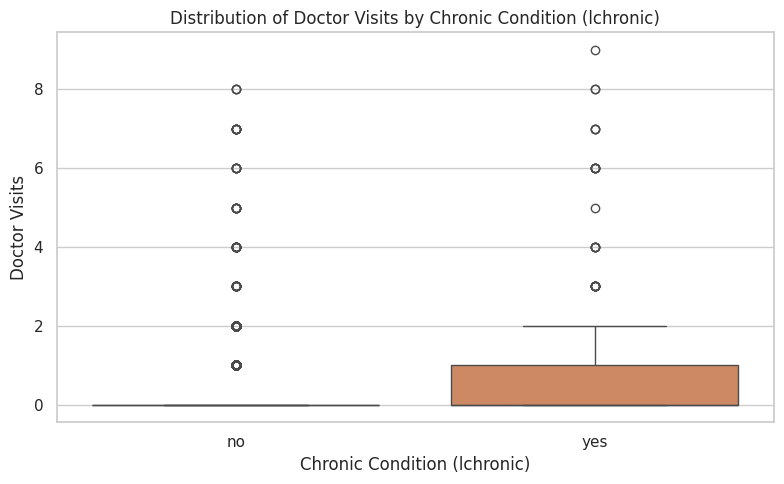

In [653]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="lchronic", y="visits", hue="lchronic", legend=False)
plt.title("Distribution of Doctor Visits by Chronic Condition (lchronic)")
plt.xlabel("Chronic Condition (lchronic)")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# **25. Multivariate Regression Analysis**

## **25.1. Feature Engineering: One-Hot Encoding Categorical Variables**
Categorical variables need to be converted into a numerical format for regression models. One-hot encoding creates new binary columns for each category, preventing the model from assuming an ordinal relationship where none exists.

In [654]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns (excluding 'visits' if it were categorical, but it's not)
categorical_features = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_features = encoder.fit_transform(data[categorical_features])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Drop original categorical columns and concatenate the encoded ones
data_encoded = pd.concat([data.drop(columns=categorical_features), encoded_df], axis=1)

display(data_encoded.head())

,visits,age,income,illness,reduced,health,gender_female,gender_male,private_no,private_yes,freepoor_no,freepoor_yes,freerepat_no,freerepat_yes,nchronic_no,nchronic_yes,lchronic_no,lchronic_yes
0,1,0.19,0.55,1,4,1,1.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
1,1,0.19,0.45,1,2,1,1.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
2,1,0.19,0.90,3,0,0,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
3,1,0.19,0.15,1,0,0,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
4,1,0.19,0.45,2,5,1,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00


## **25.2. Data Splitting: Training and Testing Sets**
The dataset is split into training and testing sets to evaluate the model's performance on unseen data. This helps in assessing the model's generalization ability and preventing overfitting.

In [655]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data_encoded.drop(columns=['visits'])
y = data_encoded['visits']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} records")
print(f"Test set size: {X_test.shape[0]} records")

Training set size: 3096 records
Test set size: 774 records


## **25.3. Model Building: Poisson Regression**
Since 'visits' is a count variable (non-negative integers), a Poisson regression model is more appropriate than ordinary least squares (OLS) regression. Poisson regression models the logarithm of the expected count as a linear combination of the predictor variables.

In [656]:
import statsmodels.api as sm

# Add a constant to the independent variables for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Build and train the Poisson regression model
poisson_model = sm.Poisson(y_train, X_train_sm)
poisson_results = poisson_model.fit(disp=False)

# Display the model summary
print(poisson_results.summary())

                          Poisson Regression Results                          
Dep. Variable:                 visits   No. Observations:                 3096
Model:                        Poisson   Df Residuals:                     3084
Method:                           MLE   Df Model:                           11
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.1460
Time:                        12:40:21   Log-Likelihood:                -2372.7
converged:                      False   LL-Null:                       -2778.3
Covariance Type:            nonrobust   LLR p-value:                7.983e-167
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1906        nan        nan        nan         nan         nan
age               0.4528      0.185      2.448      0.014       0.090       0.815
income           -0.1797      0.095     

/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


## **25.4. Model Evaluation**
Model evaluation involves assessing how well the trained model performs on the test set. For count data, metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (pseudo R-squared for GLMs) are commonly used. Given the nature of Poisson regression, it's also useful to check the goodness-of-fit using the deviance and Pearson chi-squared statistics relative to their degrees of freedom.

Mean Absolute Error (MAE): 0.53
Mean Squared Error (MSE): 0.71
Root Mean Squared Error (RMSE): 0.84


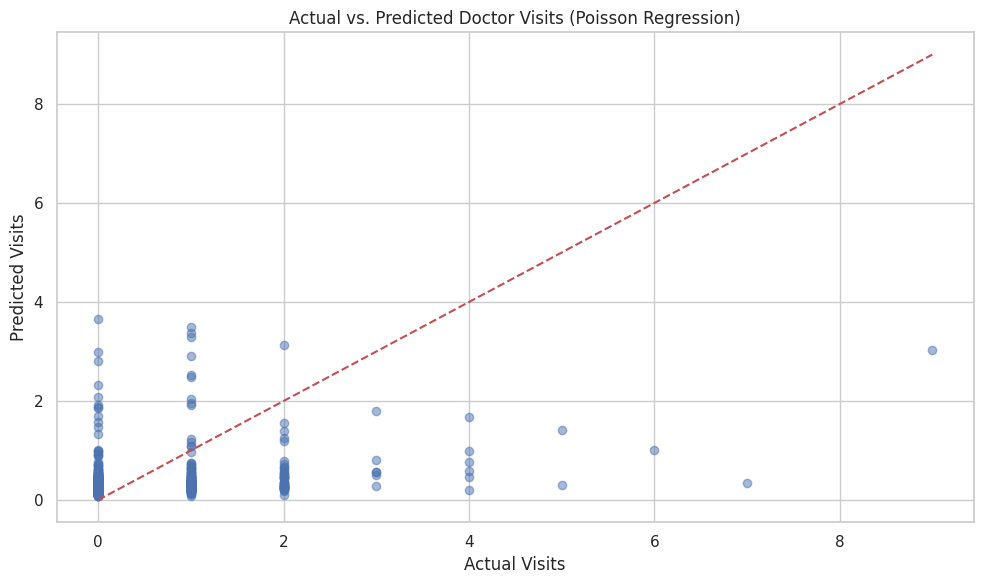

In [657]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on the test set
y_pred_poisson = poisson_results.predict(X_test_sm)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_poisson)
mse = mean_squared_error(y_test, y_pred_poisson)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

# Visualize actual vs. predicted values for a sample
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poisson, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Visits")
plt.ylabel("Predicted Visits")
plt.title("Actual vs. Predicted Doctor Visits (Poisson Regression)")
plt.tight_layout()
plt.show()

# **26**. **Income** **and** **Doctor** **Visits**

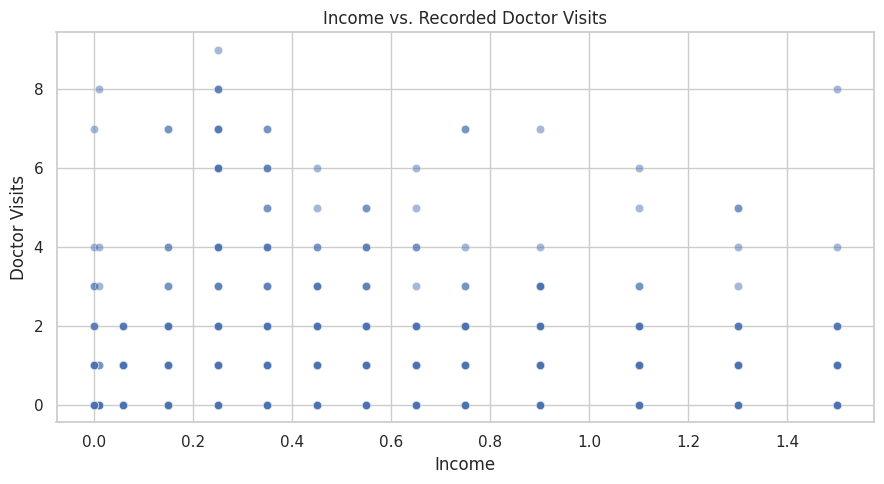

Pearson correlation between income and visits: -0.07691555133989743


In [658]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=data, x="income", y="visits", alpha=0.5)
plt.title("Income vs. Recorded Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

print("Pearson correlation between income and visits:",
      data[["income", "visits"]].corr().loc["income", "visits"])

# **27**. **Reduced** **Activity** **and** **Doctor** **Visits**

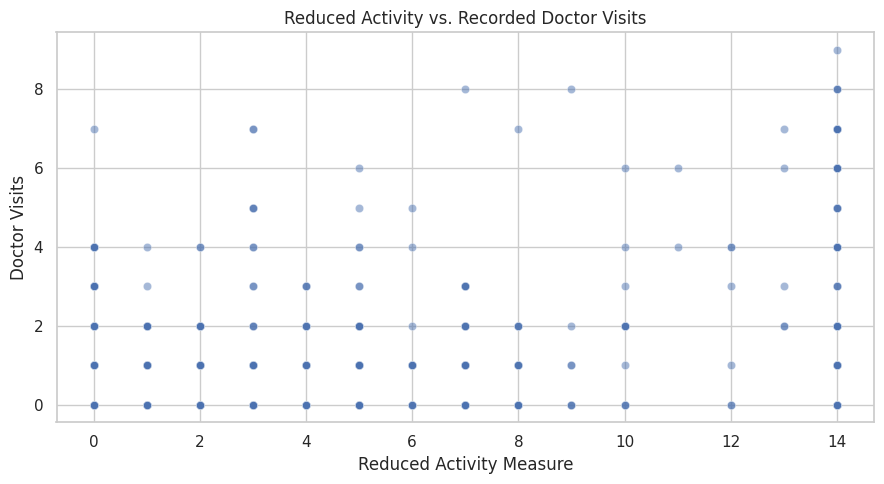

In [659]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=data, x="reduced", y="visits", alpha=0.5)
plt.title("Reduced Activity vs. Recorded Doctor Visits")
plt.xlabel("Reduced Activity Measure")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# **28**. **Correlation** **Analysis**

## Correlation is calculated only for numeric variables. It measures association, not causation.

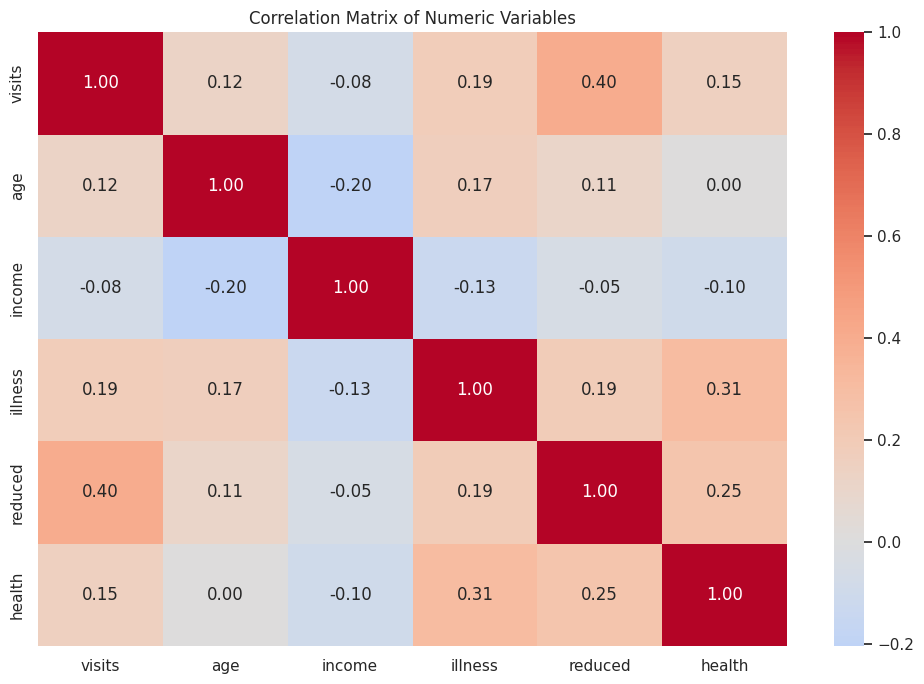

,correlation_with_visits
reduced,0.40
illness,0.19
health,0.15
age,0.12
income,-0.08


In [660]:
corr = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

# Correlations with visits
visit_corr = corr["visits"].drop("visits").sort_values(ascending=False)
display(visit_corr.to_frame("correlation_with_visits"))

# **29. Segment-Level Analysis**

## This section combines demographic and health dimensions to identify descriptive differences in average recorded visits.

,gender,nchronic,count,mean,median
1,female,yes,992,0.46,0.00
0,female,no,1076,0.44,0.00
3,male,yes,686,0.33,0.00
2,male,no,1116,0.31,0.00


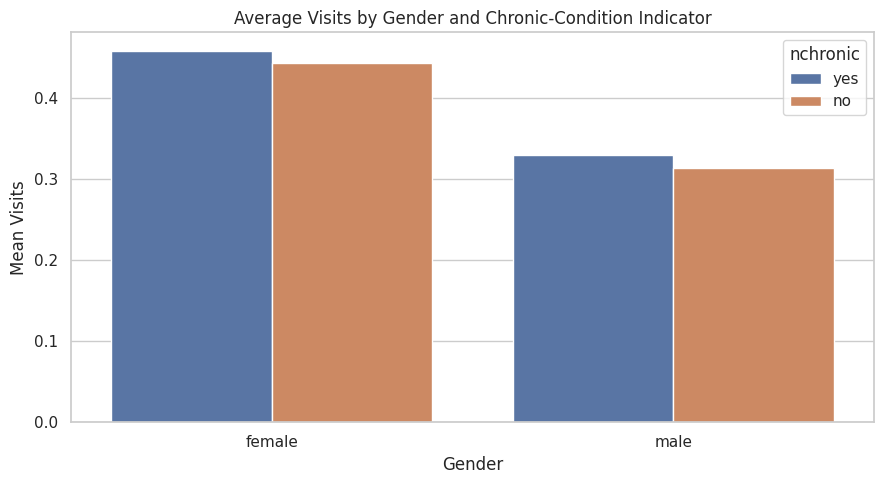

In [661]:
segment = (
    data.groupby(["gender", "nchronic"])["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
display(segment)

plt.figure(figsize=(9, 5))
sns.barplot(data=segment, x="gender", y="mean", hue="nchronic")
plt.title("Average Visits by Gender and Chronic-Condition Indicator")
plt.xlabel("Gender")
plt.ylabel("Mean Visits")
plt.legend(title="nchronic")
plt.tight_layout()
plt.show()

,gender,lchronic,count,mean,median
1,female,yes,325,0.72,0.00
3,male,yes,251,0.51,0.00
0,female,no,1743,0.40,0.00
2,male,no,1551,0.29,0.00


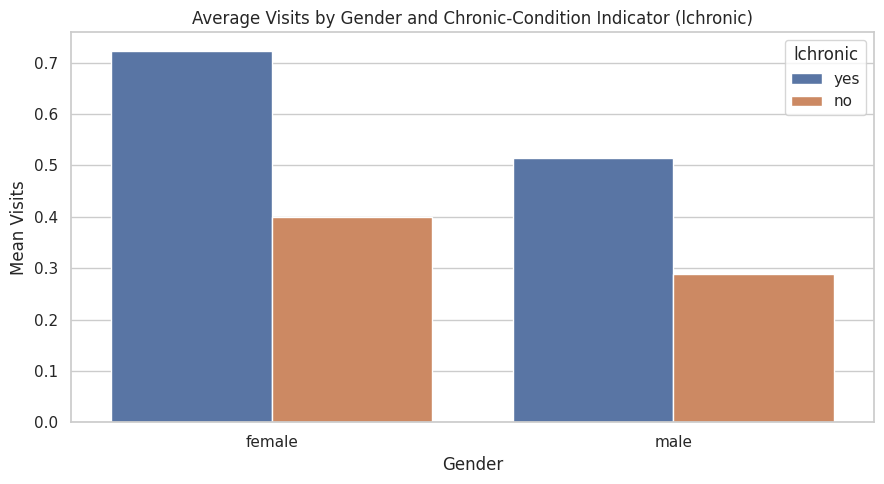

In [662]:
segment_lchronic = (
    data.groupby(["gender", "lchronic"])["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
display(segment_lchronic)

plt.figure(figsize=(9, 5))
sns.barplot(data=segment_lchronic, x="gender", y="mean", hue="lchronic")
plt.title("Average Visits by Gender and Chronic-Condition Indicator (lchronic)")
plt.xlabel("Gender")
plt.ylabel("Mean Visits")
plt.legend(title="lchronic")
plt.tight_layout()
plt.show()

# **30. High-Visit Records**

## A simple descriptive view of records with comparatively high visit counts is included below. The threshold is based on the 75th percentile rather than an arbitrary clinical definition.

In [663]:
visit_threshold = data["visits"].quantile(0.75)
high_visit = data[data["visits"] >= visit_threshold].copy()

print(f"75th-percentile visit threshold: {visit_threshold:.2f}")
print(f"Records at/above threshold: {len(high_visit):,} ({len(high_visit)/len(data)*100:.2f}%)")

display(
    high_visit[["visits", "gender", "age", "income", "illness", "reduced", "health",
                "private", "freepoor", "freerepat", "nchronic", "lchronic"]]
    .sort_values("visits", ascending=False)
    .head(10)
)

75th-percentile visit threshold: 1.00
Records at/above threshold: 990 (25.58%)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
650,9,male,0.62,0.25,5,14,10,no,no,yes,no,yes
587,8,male,0.57,0.01,1,9,4,no,no,no,no,no
513,8,male,0.52,0.25,5,14,7,no,no,yes,no,yes
729,8,male,0.67,0.25,2,14,5,no,no,yes,yes,no
47,8,female,0.19,0.25,2,7,0,no,no,no,no,yes
618,8,female,0.62,1.50,1,14,1,yes,no,no,no,no
827,7,male,0.72,0.25,3,13,6,yes,no,no,yes,no
404,7,female,0.32,0.15,4,14,0,yes,no,no,no,yes
474,7,female,0.47,0.75,5,3,2,no,no,no,no,no
855,7,female,0.72,0.25,5,14,0,no,no,yes,yes,no


## **31**. **Key** **Findings**   
Run the cells above and use the generated tables/figures to report the following categories of findings:   
*   **Dataset profile**: number of records, variables, missing values, and duplicate records.   
*   **Visit distribution**: typical visit level, spread, and whether a small group of records has substantially higher visit counts.   
*   **Demographic patterns**: differences in recorded visits across gender and age groups.   
*   **Health patterns**: relationship between illness, health measures, chronic-condition indicators, and recorded visits.   
*   **Socioeconomic/access patterns**: differences in recorded visits across income and healthcare-access indicators.   
*   **Associations**: numeric correlations with visits, interpreted descriptively rather than causally.   


## **32**. **Recommendations**   
Based on the observed patterns, a project report can consider the following data-driven recommendations:   
*   Monitor patient groups with higher recorded utilization for service-planning purposes.   
*   Examine chronic-condition and illness-related segments separately when planning healthcare resources.   
*   Use demographic and socioeconomic segmentation to understand differences in healthcare utilization.   
*   Investigate unusually high visit counts using patient-level context before drawing conclusions.   
*   Improve data documentation for coded variables so that analytical interpretations are reproducible.   
*   For future work, consider statistical modeling such as Poisson/negative-binomial regression for count outcomes, while checking model assumptions and data quality.

## **33**. **Conclusion**   
This project provides an end-to-end descriptive analysis of doctor visits using the uploaded healthcare dataset. The workflow covers data loading, quality checks, exploratory analysis, demographic segmentation, health-related analysis, healthcare-access analysis, correlation analysis, visualizations, findings, and recommendations.   
The analysis is intended for **healthcare analytics and project-reporting purposes**. Observed associations should not be interpreted as evidence that one variable causes another.

## **34**. **Summary Report of Key Findings**

### **Dataset Profile**
*   The dataset contains `3,870` unique records after removing duplicates from an initial `5,190` rows and `13` columns.
*   There are no missing values in the cleaned dataset.
*   The dataset includes `12` variables covering demographics (gender, age), socioeconomic status (income), health status (illness, reduced, health, nchronic, lchronic), healthcare access (private, freepoor, freerepat), and the primary outcome variable (visits).

### **Visit Distribution**
*   The majority of records show `0` doctor visits, with a long tail indicating a small number of individuals with higher visit counts. The mean number of visits is approximately `0.39`, while the median is `0`, suggesting a skewed distribution with many individuals having no visits and a few with multiple visits.
*   The 75th percentile for visits is `1.00`, meaning 25.58% of the records have `1` or more visits.

### **Demographic Patterns**
*   **Gender**: Females tend to have a higher average number of doctor visits (`0.45`) compared to males (`0.32`).
*   **Age**: Age shows a positive correlation with doctor visits (`0.12`). While the scatter plot shows a wide distribution, there's a slight tendency for higher visits among older individuals.

### **Health Patterns**
*   **Illness**: There is a clear positive relationship between the illness measure and average doctor visits. As illness severity increases, the mean number of visits also increases, ranging from `0.13` for `illness=0` to `0.85` for `illness=5`.
*   **Health Measure**: Similar to illness, higher health measures generally correspond to higher average doctor visits, with a notable peak at health measure `10` (`1.52` mean visits).
*   **Chronic Conditions (nchronic and lchronic)**: Individuals with chronic conditions (both `nchronic` and `lchronic`) generally have a higher mean number of doctor visits compared to those without chronic conditions.

### **Socioeconomic/Access Patterns**
*   **Income**: Income has a slight negative correlation with doctor visits (`-0.08`), suggesting that higher income might be weakly associated with fewer visits, though the relationship is not strong.
*   **Private Insurance**: Individuals with private insurance (`yes`) have a slightly lower mean number of visits (`0.37`) than those without private insurance (`no`) (`0.40`).
*   **Free Poor Status (freepoor)**: Patients with `freepoor=yes` have a lower average number of visits (`0.18`) than those with `freepoor=no` (`0.40`).
*   **Free Repatriation Status (freerepat)**: Patients with `freerepat=yes` have a significantly higher average number of visits (`0.61`) compared to those with `freerepat=no` (`0.33`).

### **Associations (Numeric Variables)**
*   **Reduced Activity (`reduced`)**: Shows the strongest positive correlation with doctor visits (`0.40`), indicating that individuals with higher reduced activity measures tend to have more doctor visits.
*   **Illness (`illness`)**: Has a positive correlation with visits (`0.19`).
*   **Health (`health`)**: Shows a positive correlation with visits (`0.15`).
*   **Age (`age`)**: Shows a positive correlation with visits (`0.12`).
*   **Income (`income`)**: Shows a weak negative correlation with visits (`-0.08`).

### **Multivariate Regression Analysis (Poisson Regression)**
*   The Poisson regression model shows that `illness`, `reduced`, and `age` are statistically significant predictors of doctor visits (low p-values).
*   `income` also shows some significance (`P>|z|=0.057`).
*   The model indicates that `illness` and `reduced` have a strong positive association with `visits` (positive coefficients), while `income` has a negative association.
*   The model fit resulted in a Pseudo R-squared of `0.1460`, indicating that the model explains a modest portion of the variance in doctor visits.
*   The evaluation metrics are: Mean Absolute Error (MAE): `0.53`, Mean Squared Error (MSE): `0.71`, Root Mean Squared Error (RMSE): `0.84`.